<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/Social_Network_Ads.csv')
df = df.iloc[:, 2:]


In [2]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [3]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)


In [4]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [5]:
# Model
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


In [6]:
model = Model()

In [7]:
# Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:

# Training
epochs = 100
val_acc_list = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 65.3125, Val Acc: 0.4000
Epoch 10, Loss: 65.3125, Val Acc: 0.4000
Epoch 20, Loss: 65.3125, Val Acc: 0.4000
Epoch 30, Loss: 65.3125, Val Acc: 0.4000
Epoch 40, Loss: 65.3125, Val Acc: 0.4000
Epoch 50, Loss: 65.3125, Val Acc: 0.4000
Epoch 60, Loss: 65.3125, Val Acc: 0.4000
Epoch 70, Loss: 65.3125, Val Acc: 0.4000
Epoch 80, Loss: 65.3125, Val Acc: 0.4000
Epoch 90, Loss: 65.3125, Val Acc: 0.4000


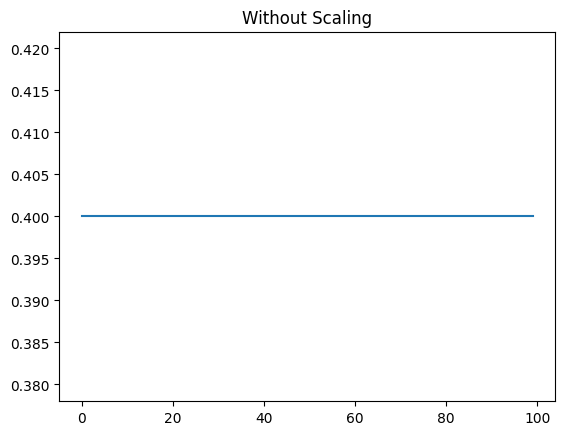

In [9]:
# Plot
plt.plot(val_acc_list)
plt.title("Without Scaling")
plt.show()

🔍 What your graph means

Validation accuracy ≈ 0.60 for all epochs

No improvement at all

Model is basically not learning anything

👉 This is exactly what we expect without scaling

Epoch 0, Loss: 0.6332, Val Acc: 0.6000
Epoch 10, Loss: 0.5551, Val Acc: 0.7625
Epoch 20, Loss: 0.4946, Val Acc: 0.7875
Epoch 30, Loss: 0.4487, Val Acc: 0.8250
Epoch 40, Loss: 0.4136, Val Acc: 0.8250
Epoch 50, Loss: 0.3861, Val Acc: 0.8375
Epoch 60, Loss: 0.3640, Val Acc: 0.8500
Epoch 70, Loss: 0.3459, Val Acc: 0.8500
Epoch 80, Loss: 0.3309, Val Acc: 0.8500
Epoch 90, Loss: 0.3182, Val Acc: 0.8625


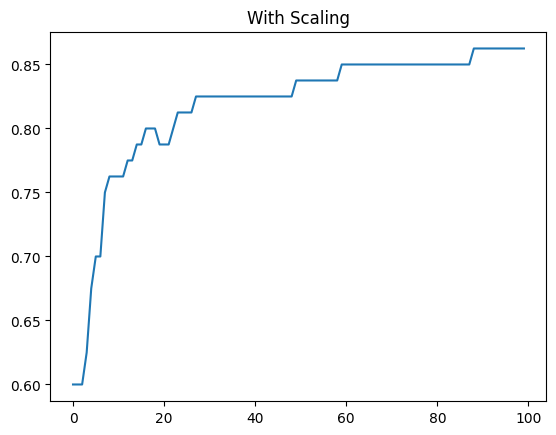

In [10]:
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

# Convert back to tensor
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)

# New model
model = Model()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
val_acc_list_scaled = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train_scaled)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test_scaled)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list_scaled.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

# Plot
plt.plot(val_acc_list_scaled)
plt.title("With Scaling")
plt.show()

🔍 What this second graph shows

Accuracy jumps quickly → ~0.88 early

Then stabilizes around 0.83–0.85

Small fluctuations (normal)

👉 Most important:

The model is actually learning now

================================================================================
# Standardization
================================================================================

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Example dataset
# =========================
X = np.array([10, 12, 14, 16, 18], dtype=float)

print("Original Data:", X)

Original Data: [10. 12. 14. 16. 18.]


In [12]:
# =========================
# 2. Manual Mean
# =========================
mean = sum(X) / len(X)
print("\nManual Mean:", mean)




Manual Mean: 14.0


In [13]:
# =========================
# 3. Manual Standard Deviation
# =========================
# Step-by-step
squared_diff = [(x - mean) ** 2 for x in X]
variance = sum(squared_diff) / len(X)
std = np.sqrt(variance)

print("Manual Variance:", variance)
print("Manual Std Dev:", std)



Manual Variance: 8.0
Manual Std Dev: 2.8284271247461903


In [14]:
# =========================
# 4. Manual Standardization
# =========================
X_standardized_manual = [(x - mean) / std for x in X]

print("\nManual Standardized Data:")
print(np.array(X_standardized_manual))




Manual Standardized Data:
[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


In [15]:
# =========================
# 5. Using StandardScaler
# =========================
scaler = StandardScaler()
X_reshaped = X.reshape(-1, 1)  # sklearn needs 2D

X_standardized_sklearn = scaler.fit_transform(X_reshaped)

print("\nSklearn Standardized Data:")
print(X_standardized_sklearn.flatten())




Sklearn Standardized Data:
[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


In [16]:
# =========================
# 6. Mean & Std after scaling
# =========================
print("\nAfter Standardization (Manual):")
print("Mean:", np.mean(X_standardized_manual))
print("Std Dev:", np.std(X_standardized_manual))

print("\nAfter Standardization (Sklearn):")
print("Mean:", X_standardized_sklearn.mean())
print("Std Dev:", X_standardized_sklearn.std())


After Standardization (Manual):
Mean: 0.0
Std Dev: 0.9999999999999999

After Standardization (Sklearn):
Mean: 0.0
Std Dev: 0.9999999999999999


================================================================================
# Normalization
================================================================================

In [17]:
import numpy as np

# Data
data = np.array([10, 11, 12])

# Manual Min-Max Normalization
x_min = np.min(data)
x_max = np.max(data)

normalized_manual = (data - x_min) / (x_max - x_min)

print("Manual Normalization:", normalized_manual)

Manual Normalization: [0.  0.5 1. ]


In [18]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Data (must be 2D for sklearn)
data = np.array([[10], [11], [12]])

scaler = MinMaxScaler()

normalized_lib = scaler.fit_transform(data)

print("Library Normalization:\n", normalized_lib)

Library Normalization:
 [[0. ]
 [0.5]
 [1. ]]
